

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>


# Gestão de experimentos (RICE) e análise de Teste A/B para otimização de funil em e-commerce. Estudo com análise estatística (Mann-Whitney U) com filtragem de outliers para validação de hipótese e otimização de conversão. 

Este projeto apresenta um estudo de caso analítico completo, nele vou exercer o papel de um Analista de Dados em uma plataforma de e-commerce. Meu objetivo principal será guiar a tomada de decisões de negócios baseada em dados para maximizar a receita, utilizando um framework robusto de priorização e experimentação. Em parceria com o time de Marketing, irei compilar e priorizar uma lista de hipóteses para otimização do funil de vendas até a tomada de decisão com a consolidação de todos os resultados estatísticos para determinar se o teste deve ser parado e qual grupo (A ou B) deve ser declarado o líder, fornecendo uma recomendação de negócio clara e baseada em evidências para a empresa.

## Parte 1 - Priorizando Hipóteses.

Antes de rodar qualquer Teste A/B, é preciso aplicar um método de priorização para decidir qual hipótese trará o maior impacto com o menor risco e menor esforço visando maior lucro para o e-commerce. O framework ICE ou sua variação RICE é o padrão de mercado para isso, dependendo de qual resultado é almejado. Antes vou carregar o conjunto de dados das hipóteses levantadas pelo Marketing e tratá-los com uma padronização a fim de evitar dados contaminados e erros futuros na fase de testes.

### Pré- processamento do DataFrame 'hypotheses'

In [3]:
import pandas as pd

# Carregar o conjunto dos dados de 'hypotheses'

hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
print(hypotheses)
print(hypotheses.info())

                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   
5  Add a customer review page. This will increase...      3       2   
6  Show banners with current offers and sales on ...      5       3   
7  Add a subscription form to all the main pages....     10       7   
8  Launch a promotion that gives users discounts ...      1       9   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  
5           2       3  
6           8       3  
7           8       5  
8           9       5  
<class 'pandas.core.frame.DataFrame'>
RangeIndex:

In [4]:
## Padronização dos nomes das colunas

# Renomear colunas para padronização
hypotheses.columns = ['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort']

# Exibir informações básicas e as primeiras linhas
print(hypotheses.info())
display(hypotheses)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes
None


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


### Aplicar o framework ICE para priorizar hipóteses. 
Ao aplicar o framework ICE (Impacto, Confiança, Esforço), vou poder quantificar e classificar as nove hipóteses propostas pelo departamento de Marketing, determinando quais delas devem ser priorizadas para a fase de testes A/B.

In [5]:
# Calcular a pontuação ICE para cada hipótese
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Classificar o DataFrame em ordem decrescente de ICE
ice_prioritization = hypotheses[['Hypothesis', 'ICE', 'Reach', 'Impact', 'Confidence', 'Effort']].sort_values(by='ICE', ascending=False)

display(ice_prioritization)

,Hypothesis,ICE,Reach,Impact,Confidence,Effort
8,Launch a promotion that gives users discounts ...,16.200000,1,9,9,5
0,Add two new channels for attracting traffic. T...,13.333333,3,10,8,6
7,Add a subscription form to all the main pages....,11.200000,10,7,8,5
6,Show banners with current offers and sales on ...,8.000000,5,3,8,3
2,Add product recommendation blocks to the store...,7.000000,8,3,7,3
1,Launch your own delivery service. This will sh...,2.000000,2,5,4,10
5,Add a customer review page. This will increase...,1.333333,3,2,2,3
3,Change the category structure. This will incre...,1.125000,8,3,3,8
4,Change the background color on the main page. ...,1.000000,3,1,1,1


A pontuação ICE permite uma alocação de recursos mais inteligente. A hipótese classificada acima em 1º lugar obteve o melhor equilíbrio entre potencial de retorno e custo. A hipótese vencedora (ICE: 16.20) é a ***Launch a promotion that gives users discounts...***, ou seja, lançar uma promoção que ofereça descontos aos usuários.

Esta hipótese apresenta um Impacto (9) e Confiança (9) muito altos, indicando que a equipe de Marketing tem forte convicção de que oferecer descontos gerará um aumento significativo na receita. Além disso, o Esforço (5) é moderado, tornando o investimento de tempo e recursos justificável.

### Aplicar o framework RICE para priorizar hipóteses. 

Analisar o mesmo conjunto de hipóteses usando frameworks diferentes, o ICE e o RICE, é fundamental para mostrar um sólido processo de priorização, destacando como o alcance (Reach) de visitantes impacta as decisões, ou seja, contabilizar quantos usuários serão afetados pela mudança.

In [6]:
# Calcular a pontuação RICE para cada hipótese
hypotheses['RICE'] = (hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']

# Classificar o DataFrame em ordem decrescente de RICE
rice_prioritization = hypotheses[['Hypothesis', 'RICE', 'Reach', 'Impact', 'Confidence', 'Effort']].sort_values(by='RICE', ascending=False)

display(rice_prioritization)

,Hypothesis,RICE,Reach,Impact,Confidence,Effort
7,Add a subscription form to all the main pages....,112.0,10,7,8,5
2,Add product recommendation blocks to the store...,56.0,8,3,7,3
0,Add two new channels for attracting traffic. T...,40.0,3,10,8,6
6,Show banners with current offers and sales on ...,40.0,5,3,8,3
8,Launch a promotion that gives users discounts ...,16.2,1,9,9,5
3,Change the category structure. This will incre...,9.0,8,3,3,8
1,Launch your own delivery service. This will sh...,4.0,2,5,4,10
5,Add a customer review page. This will increase...,4.0,3,2,2,3
4,Change the background color on the main page. ...,3.0,3,1,1,1


Ao aplicar o RICE, o ranking de prioridades sofreu uma mudança significativa, demonstrando que o potencial de impacto de algumas hipóteses não se traduz em um alto volume de usuários afetados.

Como o **objetivo é maximizar a receita, e o fator alcance determina a escala do sucesso, o framework RICE é mais adequado para a priorização em uma loja online.** Portanto, com base na análise RICE, a hipótese ***"Add a subscription form to all the main pages..."***, ou seja, adicionar um formulário de inscrição a todas as páginas principais, é a prioridade máxima e será a hipótese selecionada para ser testada na próxima fase de Teste A/B.   

Esta hipótese afetará o maior número de usuários (Reach=10), tornando esta hipótese a de maior potencial para um aumento de receita em escala, apesar do Impacto (8) e Confiança (7) serem ligeiramente menores que os da hipótese priorizada com base na análise ICE.

### Priorização de hipóteses usando RICE em vez de ICE. 

**A mudança na priorização de hipóteses ao usar o framework RICE em vez do ICE é um ponto crucial deste projeto, pois demonstra como a escala do potencial alcance (Reach) afeta as decisões de investimento**.

O principal motivo da mudança é que o RICE incorpora o alcance, isto é, quantos usuários serão afetados, enquanto o ICE foca apenas no Impacto, Confiança e Esforço. A mudança demonstra a importância de selecionar o framework correto. 

Se o objetivo da loja online fosse priorizar o **potencial de sucesso por ideia**, o ICE seria mais útil. Se o objetivo é priorizar o **potencial de sucesso em escala de negócio**, o RICE é essencial, pois garante que os recursos sejam alocados em projetos que afetam o maior número de clientes possível.

Para um **projeto de e-commerce focado em aumentar a receita total**, a hipótese ***"Add a subscription form to all the main pages..."*** (RICE 1º lugar) é a **escolha mais estratégica para o Teste A/B.**

<div class="alert alert-block alert-success">
<b> Comentário do revisor: v1 </b> <a class="tocSkip"></a>

Metodologias diferentes implementadas e comparadas conforme solicitado.

</div>




### Pré-processamento dos DataFrames 'orders' e 'visits'

Antes de prosseguir para a análise dos resultados do Teste A/B, primeiro vou pré-processar e tratar o conjunto de dados de 'orders' e 'visits' para tornar limpos e com os tipos corretos para evitar erros.

In [7]:
# Carregar conjunto de dados 'orders' e 'visits'

orders = pd.read_csv('/datasets/orders_us.csv', sep=',')
visits = pd.read_csv('/datasets/visits_us.csv', sep=',')

print(orders)
print(orders.info())

print(visits)
print(visits.info())

      transactionId   visitorId        date  revenue group
0        3667963787  3312258926  2019-08-15     30.4     B
1        2804400009  3642806036  2019-08-15     15.2     B
2        2961555356  4069496402  2019-08-15     10.2     A
3        3797467345  1196621759  2019-08-15    155.1     B
4        2282983706  2322279887  2019-08-15     40.5     B
...             ...         ...         ...      ...   ...
1192     2662137336  3733762160  2019-08-14    100.8     B
1193     2203539145   370388673  2019-08-14     50.1     A
1194     1807773912   573423106  2019-08-14    165.3     A
1195     1947021204  1614305549  2019-08-14      5.5     A
1196     3936777065  2108080724  2019-08-15   3120.1     B

[1197 rows x 5 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-

In [8]:
# Padronizar os nomes nas colunas em 'visits' e 'orders' 

visits.columns = ['date', 'group', 'visits']
orders.columns = ['transaction_id', 'visitor_id', 'date', 'revenue', 'group']

# Converter a coluna 'date' para o formato datetime em 'visits' e 'orders'

visits['date'] = pd.to_datetime(visits['date'])
orders['date'] = pd.to_datetime(orders['date'])

# Visualizar as colunas com os nomes e tipos corretos

visits.info()
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1197 non-null   int64         
 1   visitor_id      1197 non-null   int64         
 2   date            1197 non-null   datetime64[ns]
 3   revenue         1197 non-null   float64       
 4   group           1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB


### Remover usuários contaminados (visitantes que podem ter entrado no grupo A e grupo B).

Para garantir que cada usuário contribua para apenas um grupo, tornando a comparação entre os grupos A e B justa e estatisticamente válida, é primordial remover esses usuários contaminados do DataFrame 'orders'.

A razão é a validade estatística desse estudo. **Se um usuário participar de ambos os grupos, ele é considerado contaminado e viola o princípio de independência dos grupos.** Os pedidos e visitas desse usuário contaminado serão contados duas vezes, ou seja, uma vez para cada grupo, o que acarreta na distorção de métricas como a Taxa de Conversão e a Receita Média por Usuário, gerando viés nos resultados, o que pode acarretar na rejeição da hipótese nula com base em dados duplicados. Isso invalidaria todo o Teste A/B.


In [9]:
# Identificação de usuários contaminados (Cross-Group Assignment)

# Obter o conjunto de IDs únicos em cada grupo
visitors_A = set(orders[orders['group'] == 'A']['visitor_id'].unique())
visitors_B = set(orders[orders['group'] == 'B']['visitor_id'].unique())

# Encontrar a intersecção (IDs contaminados)
contaminated_visitors = visitors_A.intersection(visitors_B)
print(contaminated_visitors)

{3957174400, 3984495233, 2780786433, 1294878855, 1648269707, 1614305549, 4120364173, 232979603, 199603092, 4266935830, 2712142231, 2587333274, 2716752286, 3891541246, 1668030113, 2654030115, 3234906277, 1230306981, 1404934699, 3803269165, 2949041841, 237748145, 457167155, 2927087541, 1738359350, 3062433592, 3656415546, 818047933, 393266494, 963407295, 471551937, 2579882178, 3202540741, 2686716486, 1333886533, 2044997962, 3941795274, 1801183820, 2378935119, 4256040402, 4069496402, 3766097110, 8300375, 351125977, 1602967004, 276558944, 2038680547, 3951559397, 3963646447, 4186807279, 3717692402, 1959144690, 2458001652, 2600415354, 2954449915, 1316129916, 477780734, 3972127743}


In [10]:
# Remover os visitantes contaminados
orders_clean = orders[~orders['visitor_id'].isin(contaminated_visitors)]

# Verificação pós-limpeza
initial_orders_count = len(orders)
clean_orders_count = len(orders_clean)

print(f'Total de pedidos ANTES da limpeza: {initial_orders_count}')
print(f'Total de pedidos APÓS a limpeza: {clean_orders_count}')
print(f'Número de pedidos REMOVIDOS: {initial_orders_count - clean_orders_count}')


Total de pedidos ANTES da limpeza: 1197
Total de pedidos APÓS a limpeza: 1016
Número de pedidos REMOVIDOS: 181


In [11]:
# Substituir o DataFrame 'orders' original pelo limpo '
orders = orders_clean
orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1016 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1016 non-null   int64         
 1   visitor_id      1016 non-null   int64         
 2   date            1016 non-null   datetime64[ns]
 3   revenue         1016 non-null   float64       
 4   group           1016 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 47.6+ KB


Com os dados de 'orders' e 'visits' limpos e prontos, e com os tipos corretos, posso prosseguir para a fase de análise dos resultados do Teste A/B. 

<div class="alert alert-block alert-success">
<b> Comentário do revisor: v1 </b> <a class="tocSkip"></a>

Unicidade por grupos garantida conforme roteiro.

</div>

## Parte 2 - Análise de Teste A/B.

### 1. Gráfico da receita acumulada por grupo. 

Agora que os dados estão carregados e limpos de contaminação vou iniciar a análise do Teste A/B visualizando as métricas acumuladas por grupo. O primeiro passo é calcular a receita acumulada para os grupos A e B ao longo do tempo.

In [12]:
import pandas as pd
import numpy as np

# Agrupar pedidos diários por data e grupo em daily_orders
daily_orders = orders.groupby(['date', 'group']).agg({
    'visitor_id': 'nunique',
    'transaction_id': 'nunique',
    'revenue': 'sum'
}).reset_index()

daily_orders.columns = ['date', 'group', 'daily_users_with_orders', 'daily_orders', 'daily_revenue']

# Calcular os dados acumulados de pedidos e receita
# Criar uma tabela de mapeamento de datas e grupos em dates_groups
dates_groups = daily_orders[['date', 'group']].drop_duplicates().sort_values(by='date')

# Calcular os pedidos e receita acumulada criando o DataFrame 'cumulative_orders'
cumulative_orders = dates_groups.apply(
    lambda x: daily_orders[
        (daily_orders['date'] <= x['date']) & (daily_orders['group'] == x['group'])
    ].agg({
        'date': 'max',
        'group': 'max',
        'daily_orders': 'sum',
        'daily_revenue': 'sum'
    }),
    axis=1
).rename(
    columns={'daily_orders': 'cumulative_orders', 'daily_revenue': 'cumulative_revenue'}
)

# Calcular DataFrame de visitas acumuladas em cumulative_visits
cumulative_visits = visits.sort_values(by=['date', 'group'])
cumulative_visits['cumulative_visits'] = cumulative_visits.groupby('group')['visits'].cumsum()
cumulative_visits = cumulative_visits[['date', 'group', 'cumulative_visits']]


# 4. Unir todos os dados em um único DataFrame acumulado em cumulative_data
cumulative_data = cumulative_orders.merge(cumulative_visits, on=['date', 'group'])

display(cumulative_data.head(10))
cumulative_data.info()

,date,group,cumulative_orders,cumulative_revenue,cumulative_visits
0,2019-08-01,A,23,2266.6,719
1,2019-08-01,B,17,967.2,713
2,2019-08-02,A,42,3734.9,1338
3,2019-08-02,B,40,3535.3,1294
4,2019-08-03,A,66,5550.1,1845
5,2019-08-03,B,54,4606.9,1803
6,2019-08-04,A,77,6225.6,2562
7,2019-08-04,B,68,6138.5,2573
8,2019-08-05,A,99,7623.6,3318
9,2019-08-05,B,89,7587.8,3280


<class 'pandas.core.frame.DataFrame'>
Int64Index: 62 entries, 0 to 61
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                62 non-null     datetime64[ns]
 1   group               62 non-null     object        
 2   cumulative_orders   62 non-null     int64         
 3   cumulative_revenue  62 non-null     float64       
 4   cumulative_visits   62 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 2.9+ KB


Estruturei os DataFrames acumulados, combinando os pedidos 'orders' com as visitas diárias 'visits'. O  DataFrame 'cumulative_data' está pronto, e agora posso prosseguir com a geração do Gráfico da Receita Acumulada para melhor visualização.

Para visualização do gráfico denominei o Grupo A como Controle e o Grupo B como Variante seguindo a nomenclatura padrão em Testes A/B. Essa denominação é usada para clareza e padronização na análise. O Grupo A (Controle) representa a versão atual, original, ele serve como o ponto de referência, o "controle" contra o qual o desempenho da nova versão será medido. Os usuários neste grupo veem a experiência que existia antes do início do teste.

O Grupo B (Variante) é o experimental, ele representa a nova versão que contém a mudança ou melhoria proposta pela hipótese de adicionar um formulário de subscrição ou lançar uma promoção. O objetivo é determinar se esta "variante" tem um desempenho estatisticamente diferente, e melhor, do que o grupo de controle A.

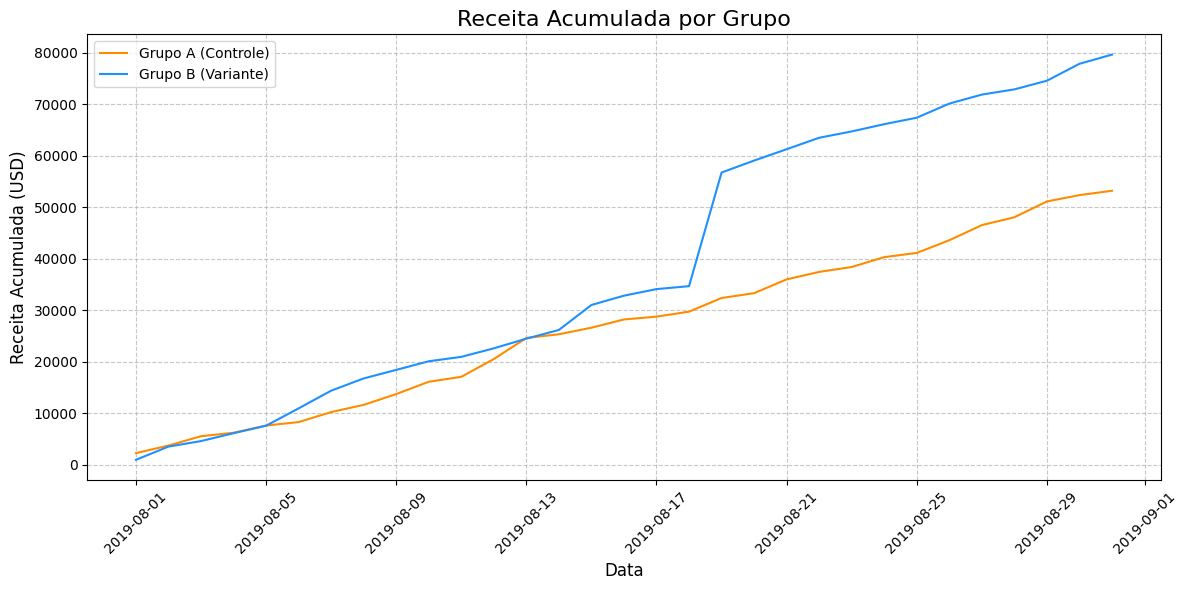

In [13]:
import matplotlib.pyplot as plt

# Filtrar dados para o grupo A
cumulative_revenue_A = cumulative_data[cumulative_data['group'] == 'A'][['date', 'cumulative_revenue']]
# Filtrar dados para o grupo B
cumulative_revenue_B = cumulative_data[cumulative_data['group'] == 'B'][['date', 'cumulative_revenue']]

# Configuração e geração do gráfico
plt.figure(figsize=(12, 6))

# Plotar as linhas de receita acumulada
plt.plot(cumulative_revenue_A['date'], cumulative_revenue_A['cumulative_revenue'], label='Grupo A (Controle)', color='darkorange')
plt.plot(cumulative_revenue_B['date'], cumulative_revenue_B['cumulative_revenue'], label='Grupo B (Variante)', color='dodgerblue')

# Configurações do título e Eixos X e Y do gráfico
plt.title('Receita Acumulada por Grupo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Receita Acumulada (USD)', fontsize=12)

# Adicionar legenda, grade e formatar eixos
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout() # Ajusta o layout para evitar cortes
plt.show()

Ao observar o gráfico da Receita Acumulada (Grupo A em laranja, Grupo B em azul), podemos concluir que o Grupo B apresenta desempenho superior. A linha da Receita Acumulada do Grupo B (variante) se mantém consistentemente acima da linha do Grupo A (controle) por quase todo o período do teste. Isso sugere que, em termos de valor monetário total, a alteração proposta da hipótese selecionada ("Add a subscription form to all the main pages...") está gerando mais receita bruta.

Contudo, o gráfico também aponta um outlier extremo. **Por volta do dia 2019-08-18 ou logo após, há um pico vertical abrupto e significativo na linha do Grupo B. Este é o ponto mais importante da análise.** O pico vertical indica que um ou poucos pedidos com valores extremamente altos ocorreram no Grupo B naquele dia. **Essa análise gera a necessidade de filtrar os outliers.** A diferença de receita pode não ser devido à eficácia da variante, mas sim à sorte de ter um cliente de alto valor no Grupo B.

A Receita Média por Usuário do **Grupo B está artificialmente inflacionada por esses pedidos gigantes de algum usuário.** Por essa razão é primordial **remover ou limitar o efeito desses outliers** para que o teste seja uma medida da performance de usuários médios da hipótese.

A conclusão de que o grupo B é melhor que grupo A baseada apenas neste gráfico de Receita Acumulada por Grupo é prematura e arriscada. **Os outliers mencionados violam as suposições de normalidade necessárias para alguns testes estatísticos.** Dessa forma, o uso de testes não-paramétricos, como o teste de Mann-Whitney U, se apresenta como essencial nessa análise.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Receita acumulada investigada.
</div>


### 2. Gráfico do tamanho médio acumulado do pedido por grupo (Ticket Médio Acumulado - AOV).

Para dar sequência e investigar a causa do pico na receita acumulada no gráfico acima, o passo fundamental é analisar o tamanho médio acumulado do pedido, também conhecido como Ticket Médio Acumulado ou AOV - Average Order Value.

O gráfico AOV ajudará a visulizar se a diferença na receita é impulsionada por um volume maior de pedidos, mais usuários comprando, ou por pedidos mais caros de alguns usuários.

In [14]:
# Calcular o Ticket Médio Acumulado (AOV)
cumulative_data['cumulative_aov'] = cumulative_data['cumulative_revenue'] / cumulative_data['cumulative_orders']

# Exibir as 10 primeiras linhas com o novo cálculo
display(cumulative_data.head(10))

,date,group,cumulative_orders,cumulative_revenue,cumulative_visits,cumulative_aov
0,2019-08-01,A,23,2266.6,719,98.547826
1,2019-08-01,B,17,967.2,713,56.894118
2,2019-08-02,A,42,3734.9,1338,88.926190
3,2019-08-02,B,40,3535.3,1294,88.382500
4,2019-08-03,A,66,5550.1,1845,84.092424
5,2019-08-03,B,54,4606.9,1803,85.312963
6,2019-08-04,A,77,6225.6,2562,80.851948
7,2019-08-04,B,68,6138.5,2573,90.272059
8,2019-08-05,A,99,7623.6,3318,77.006061
9,2019-08-05,B,89,7587.8,3280,85.256180


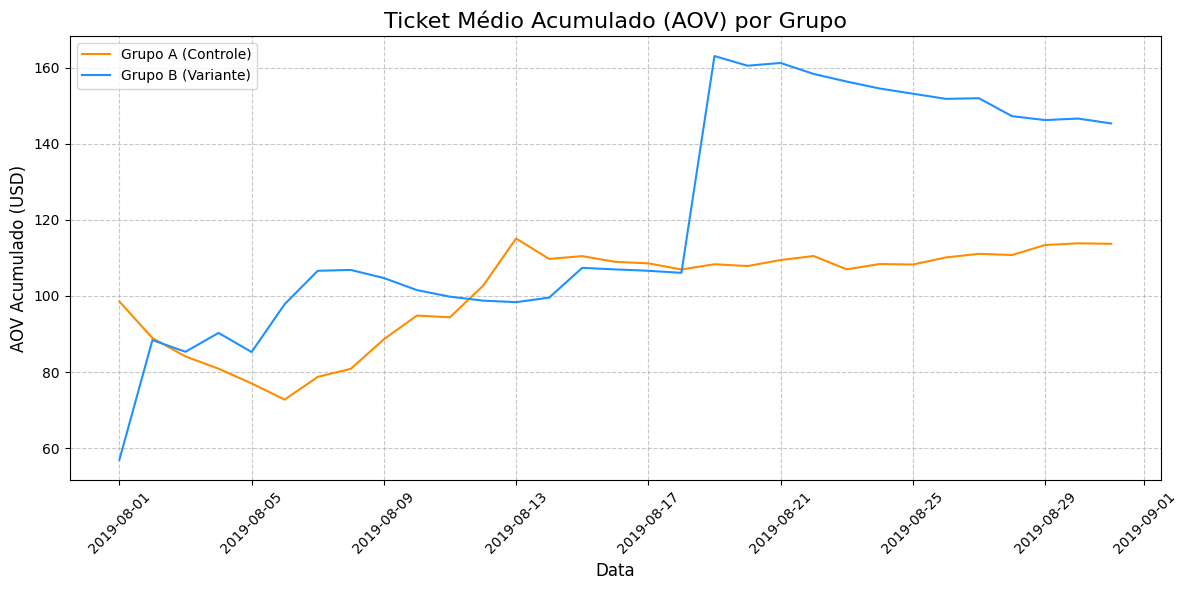

In [15]:
# Filtrar dados para os respectivos grupos
cumulative_aov_A = cumulative_data[cumulative_data['group'] == 'A'][['date', 'cumulative_aov']]
cumulative_aov_B = cumulative_data[cumulative_data['group'] == 'B'][['date', 'cumulative_aov']]

# Configuração e geração do gráfico
plt.figure(figsize=(12, 6))

# Plotar as linhas do AOV acumulado
plt.plot(cumulative_aov_A['date'], cumulative_aov_A['cumulative_aov'], label='Grupo A (Controle)', color='darkorange')
plt.plot(cumulative_aov_B['date'], cumulative_aov_B['cumulative_aov'], label='Grupo B (Variante)', color='dodgerblue')

# Configurações do título e eixos
plt.title('Ticket Médio Acumulado (AOV) por Grupo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('AOV Acumulado (USD)', fontsize=12)

# Adicionar legenda, grade e formatar eixos
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O comportamento da curva do Grupo B no gráfico acima do Ticket Médio Acumulado (AOV) é similar ao que foi observado no gráfico da Receita Acumulada anteriormente. Ambos os gráficos apresentam o Grupo B com uma performance superior e, crucialmente, mostram o mesmo pico vertical abrupto e significativo em torno de 2019-08-18 ou logo após. **Essa similaridade e o pico confirmam a presença de outliers extremos** e fornecem insights importantes para a análise.

A semelhança entre as curvas confirma que o aumento repentino na Receita Acumulada do Grupo B não foi devido a um aumento repentino no número de pedidos, mas sim devido a um ou poucos pedidos com valores extremamente altos que entraram no cálculo do Ticket Médio Acumulado (AOV).

Verifica-se ainda que após o pico, a curva do Grupo B não retorna imediatamente ao nível do Grupo A,  ela se mantém elevada e demora a convergir. Isso sugere que o valor dos pedidos outliers foi tão alto que o influxo de pedidos "normais" subsequentes ainda não foi suficiente para diluir totalmente seu efeito no valor médio acumulado. O teste ainda está distorcido.**Ambos os gráficos Receita e AOV gritam "Outliers!".** 

A principal implicação dessa análise visual é que a diferença entre os grupos em termos de Receita e AOV pode ser uma ilusão estatística. Para avançar com confiança, é necessário a identificação dos Outliers, ou seja, determinar o que constitui um valor de pedido anormalmente alto.

Na análise **entendo que se torna primordial remover ou limitar o impacto desses outliers nos DataFrames 'orders' para realizar um Teste de Significância Estatística mais confiável.**


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Ticket médio investigado por meio de gráficos e conclusões adequadas.

</div>

### 3. Gráfico da diferença relativa no Tamanho Médio Acumulado (AOV) do pedido para o grupo B em comparação com o grupo A.

A análise da diferença relativa acumulada é o próximo passo lógico dessa análise. Ela irá traduzir a distância entre as duas curvas (AOV do Grupo A e AOV do Grupo B) em uma única linha, facilitando a visualização da tendência e da estabilidade da variação encontrada.

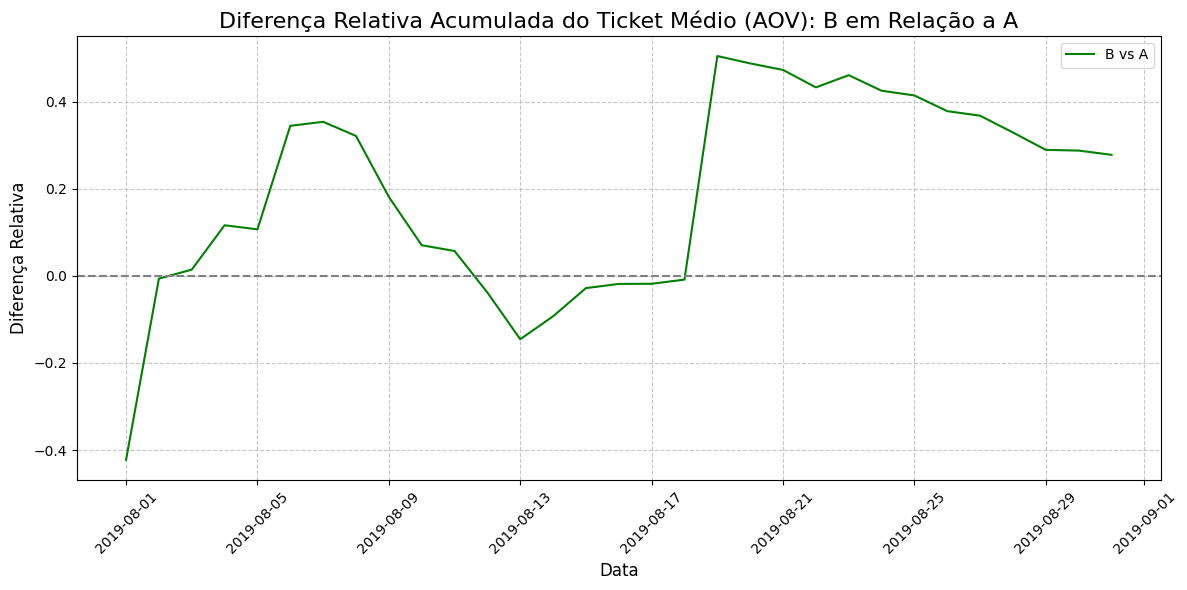

In [16]:
# Separar o AOV acumulado por grupo (certificando-se de que as datas estão alinhadas)
cumulative_aov_A = cumulative_data[cumulative_data['group'] == 'A'][['date', 'cumulative_aov']]
cumulative_aov_B = cumulative_data[cumulative_data['group'] == 'B'][['date', 'cumulative_aov']]

# Renomear as colunas de AOV para facilitar a distinção após o merge
cumulative_aov_A = cumulative_aov_A.rename(columns={'cumulative_aov': 'aov_A'})
cumulative_aov_B = cumulative_aov_B.rename(columns={'cumulative_aov': 'aov_B'})

# Juntar os DataFrames de AOV dos dois grupos pela data 'date'
merged_aov = cumulative_aov_A.merge(cumulative_aov_B, on='date', how='left')

# Calcular a diferença relativa do AOV (B em relação a A)
merged_aov['relative_difference'] = (merged_aov['aov_B'] / merged_aov['aov_A']) - 1

# Configuração e Geração do Gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plotar a diferença relativa
plt.plot(merged_aov['date'], merged_aov['relative_difference'], label='B vs A', color='green')

# Adicionar a linha horizontal do zero (baseline)
plt.axhline(y=0, color='gray', linestyle='--')

# Configurações do título e eixos
plt.title('Diferença Relativa Acumulada do Ticket Médio (AOV): B em Relação a A', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Diferença Relativa', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Veja bem como a forma da linha de diferença relativa acumulada do Ticket Médio (AOV) se comporta. Esta é a prova visual mais forte da presença de outliers extremos.

O gráfico da Diferença Relativa mostra a instabilidade e o impacto dos pedidos atípicos de forma percentual. O pico vertical abrupto, próximo a 0.50 ou 50%, que ocorre por volta de 2019-08-20 confirma o que foi observado nos gráficos anteriores. Este pico significa que o AOV acumulado do Grupo B saltou para um valor significativamente maior do que o do Grupo A em um único ponto. Isso só é possível devido à inclusão de um ou mais pedidos com valores muito superiores ao valor médio normal, ou seja, **esta é a confirmação do outlier com a visualização do pico extremo no gráfico.**

O gráfico é altamente volátil. O AOV começa com uma grande diferença negativa, sobe para um grande pico positivo, e depois se estabiliza em um patamar positivo alto, mas não converge para zero, o que indicaria que a hipótese não fez diferença, e também nem para uma linha reta estável acima do zero. Essa análise gráfica demonstra claramente uma instabilidade e falta de convergência. 

Tem-se aqui um resultado distorcido. A diferença positiva no final do teste é artificialmente inflacionada pelo outlier. Sem ele, a diferença real seria menor e possivelmente não estatisticamente significativa.

Há um viés na métrica AOV (Tamanho Médio do Pedido) pois ela é altamente sensível a outliers e, neste caso, é inconfiável para tirar conclusões. Dessa forma, **devo priorizar métricas menos sensíveis a valores extremos, como por exemplo a Taxa de Conversão, ou aplicar o tratamento de outliers.**

Se eu concluísse que o Grupo B é melhor apenas com base neste AOV, correria o risco de gastar recursos implementando uma mudança que, na realidade, não aumenta o gasto do cliente médio. **O comportamento caótico da linha de diferença relativa torna o teste realizado nesse gráfico inconclusivo no que diz respeito ao AOV.**


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Ticket médio endereçado também em abordagem relativa.

</div>

### 4. Cálculo da taxa de conversão de cada grupo como a proporção de pedidos para o número de visitas para cada dia. 

Agora vou analisar a métrica de desempenho mais fundamental em um e-commerce, a Taxa de Conversão. Esta métrica mede a eficiência do site em transformar visitantes em clientes, impactando diretamente o ROI, a rentabilidade e a previsibilidade de receita, ao mostrar se as estratégias de marketing trazem retorno ou geram desperdício de dinheiro, além de indicar a qualidade da experiência do usuário e a performance do funil de vendas.

Ao contrário da Receita e do AOV, a Taxa de Conversão é muito menos suscetível a outliers de valores monetários, tornando-a uma métrica mais estável e confiável para avaliar a eficácia da sua hipótese em incentivar os usuários a fazerem uma compra.

Para calcular a taxa de conversão acumulada diária, irei usar o DataFrame que criei denominado 'cumulative_data', que contém as colunas de pedidos acumulados ('cumulative_orders'), e as visitas acumuladas ('cumulative_visits').

In [17]:
# Calcular a taxa de conversão acumulada
cumulative_data['cumulative_conversion'] = cumulative_data['cumulative_orders'] / cumulative_data['cumulative_visits']

# Separar as taxas de conversão por grupo
cumulative_conversion_A = cumulative_data[cumulative_data['group'] == 'A'][['date', 'cumulative_conversion']]
cumulative_conversion_B = cumulative_data[cumulative_data['group'] == 'B'][['date', 'cumulative_conversion']]

display(cumulative_data.head(10))

,date,group,cumulative_orders,cumulative_revenue,cumulative_visits,cumulative_aov,cumulative_conversion
0,2019-08-01,A,23,2266.6,719,98.547826,0.031989
1,2019-08-01,B,17,967.2,713,56.894118,0.023843
2,2019-08-02,A,42,3734.9,1338,88.926190,0.031390
3,2019-08-02,B,40,3535.3,1294,88.382500,0.030912
4,2019-08-03,A,66,5550.1,1845,84.092424,0.035772
5,2019-08-03,B,54,4606.9,1803,85.312963,0.029950
6,2019-08-04,A,77,6225.6,2562,80.851948,0.030055
7,2019-08-04,B,68,6138.5,2573,90.272059,0.026428
8,2019-08-05,A,99,7623.6,3318,77.006061,0.029837
9,2019-08-05,B,89,7587.8,3280,85.256180,0.027134


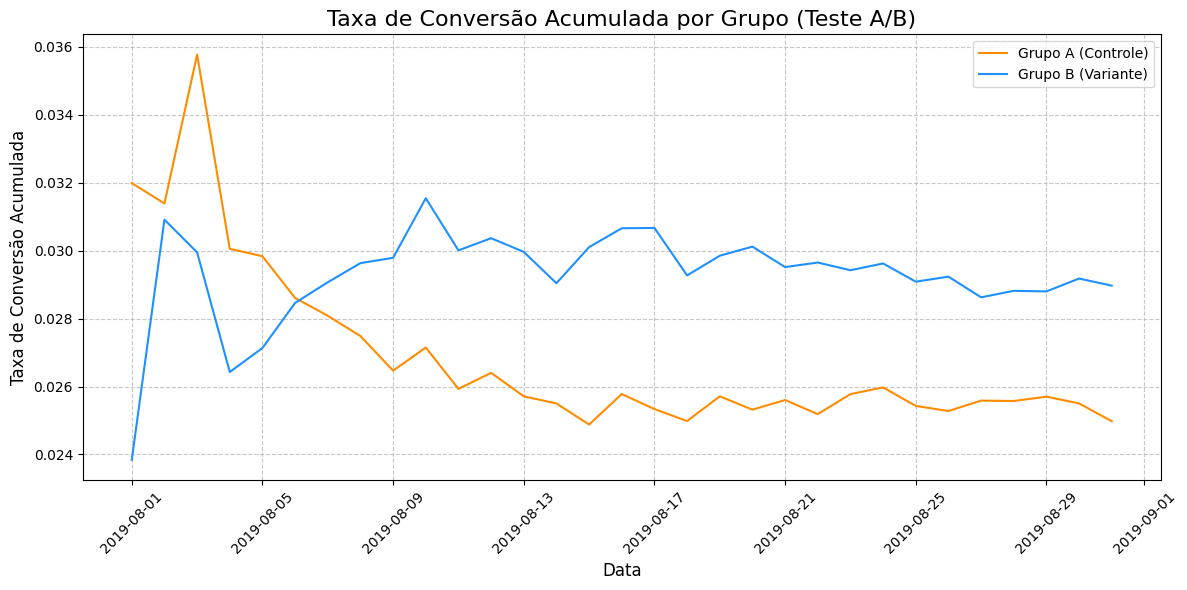

In [18]:
# Configuração e Geração do Gráfico
plt.figure(figsize=(12, 6))

# Plotar as linhas da Taxa de Conversão Acumulada
plt.plot(cumulative_conversion_A['date'], cumulative_conversion_A['cumulative_conversion'], label='Grupo A (Controle)', color='darkorange')
plt.plot(cumulative_conversion_B['date'], cumulative_conversion_B['cumulative_conversion'], label='Grupo B (Variante)', color='dodgerblue')

# Configurações do título e eixos
plt.title('Taxa de Conversão Acumulada por Grupo (Teste A/B)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Taxa de Conversão Acumulada', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y') # Remove notação científica
plt.tight_layout()
plt.show()


O resultado do gráfico de Taxa de Conversão demonstra curvas mais suaves, que me parece ser menos afetados a outliers. O grupo B está com suas curvas mais acima em relação ao grupo A, e se mantém. **Esse resultado demonstra que o grupo B pode converter mais visitantes em compradores por conta do número maior de usuários.** Fato é que o gráfico de Taxa de Conversão Acumulada é fundamentalmente diferente dos gráficos de Receita e AOV.

As curvas são muito mais suaves e não apresentam os picos verticais abruptos vistos nas métricas monetárias (Receita e AOV). Isso confirma que **a Taxa de Conversão é uma métrica muito mais sólida e confiável para avaliar o sucesso da hipótese, pois ela mede o comportamento de compra, e não o valor gasto pelo usuário, sendo imune a grandes pedidos únicos que geram outliers.**

Em suma, o Grupo B (Variante) se mantém consistentemente acima do Grupo A (Controle) na maior parte do período do teste, especialmente após os primeiros dias de estabilização, tornando a linha do gráfico de Diferença Relativa da Conversão minha prova final de eficácia. A estabilização significa que o teste atingiu a duração necessária. O resultado é consistente.

Fica clara a vitória do grupo B (Variante) pois a linha está estabilizada e acima de zero, o que me faz concluir que o Grupo B tem uma Taxa de Conversão estatisticamente maior do que o Grupo A.

### 5. Gráfico da Diferença Relativa na Conversão cumulativa para o grupo B em comparação com o grupo A.

A análise da Diferença Relativa na Conversão Acumulada é uma espécie de uma lente de aumento com foco na métrica chave, a Taxa de Conversão.

Acima ficou claro que o Grupo B está consistentemente acima do Grupo A, mas agora é preciso quantificar e visualizar essa diferença percentual para entender a magnitude da melhoria da variante B sobre A. A ideia é analisar a estabilidade, se essa diferença está se estabilizando em um valor consistente, ou ainda está flutuando muito.

A Diferença Relativa elimina a necessidade de comparar duas linhas separadas como no gráfico de conversão simples, e foca em uma única linha que representa o ganho percentual diário do Grupo B em relação ao Grupo A.

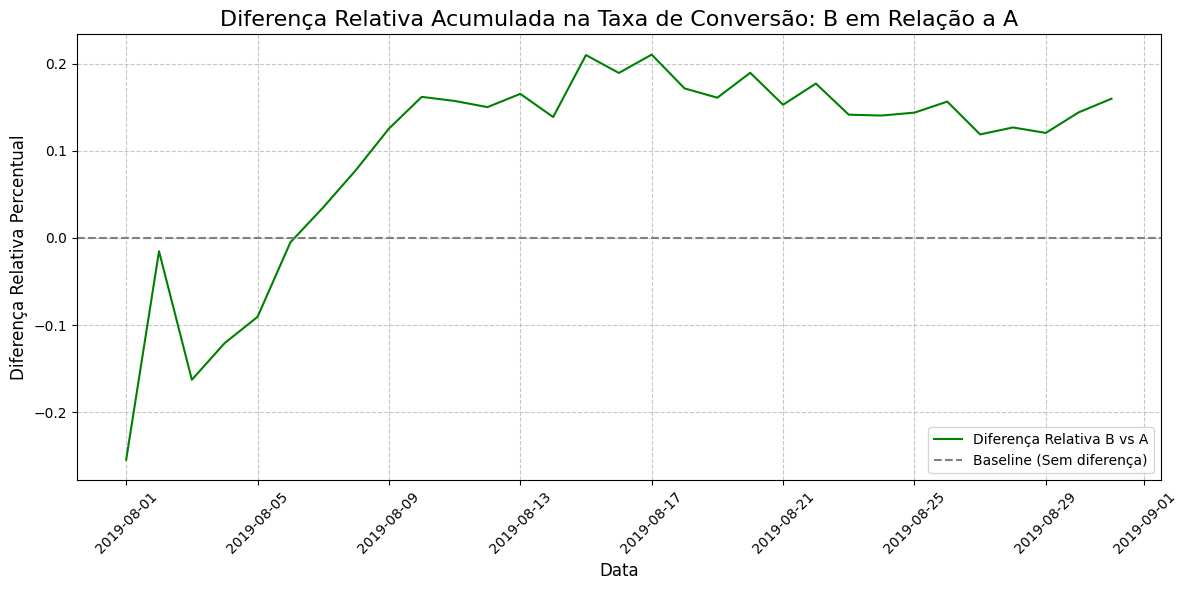

In [19]:
import matplotlib.pyplot as plt

# Separar a Conversão Acumulada por grupo (garantindo alinhamento de datas)
cumulative_conversion_A = cumulative_data[cumulative_data['group'] == 'A'][['date', 'cumulative_conversion']]
cumulative_conversion_B = cumulative_data[cumulative_data['group'] == 'B'][['date', 'cumulative_conversion']]

# Renomear colunas para merge
cumulative_conversion_A = cumulative_conversion_A.rename(columns={'cumulative_conversion': 'conv_A'})
cumulative_conversion_B = cumulative_conversion_B.rename(columns={'cumulative_conversion': 'conv_B'})

# Juntar os DataFrames pelas datas 'date'
# Fazer Merge na coluna 'date' para que a comparação seja feita dia a dia
merged_conversion = cumulative_conversion_A.merge(cumulative_conversion_B, on='date', how='left')

# Calcular a diferença relativa da Conversão (B em relação a A)
merged_conversion['relative_difference'] = (merged_conversion['conv_B'] / merged_conversion['conv_A']) - 1

# Configuração e geração do gráfico
plt.figure(figsize=(12, 6))

# Plotar a diferença relativa
plt.plot(merged_conversion['date'], merged_conversion['relative_difference'], label='Diferença Relativa B vs A', color='green')

# Adicionar a linha horizontal do zero (baseline)
plt.axhline(y=0, color='gray', linestyle='--', label='Baseline (Sem diferença)')

# Configurações do Título e Eixos
plt.title('Diferença Relativa Acumulada na Taxa de Conversão: B em Relação a A', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Diferença Relativa Percentual', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O gráfico acima da direfença relativa acumulada na Taxa de Conversão é a **prova visual mais convincente até agora do sucesso da variante B na métrica de comportamento do usuário.** A linha da diferença relativa, após a instabilidade inicial, se mantém consistentemente acima do zero durante a maior parte do teste, demonstrando a vitória clara da Variante B em relação ao Controle A.

A magnitude do lift (melhoria) pode ser interpretada quando a linha se estabiliza em torno de +0.10 a +0.15 (ou 10% a 15% acima da linha de base). Isso significa que, em média, a Taxa de Conversão do Grupo B é 10% a 15% maior do que a do Grupo A. A linha mostra uma volatilidade inicial nos primeiros dias, mas depois exibe uma tendência clara de estabilização e não retorna ao zero. Isso indica que a duração do teste está sendo suficiente para que a diferença de conversão seja real e consistente, e não apenas uma flutuação aleatória, o que torna claro a estabilidade e confiabilidade da métrica.

O resultado confirma que **a alteração implementada na Variante B é eficaz em incentivar mais visitantes a se tornarem compradores. Isso valida a escolha de priorização feita com RICE, que selecionou uma hipótese de alto alcance.**

Este gráfico contrasta fortemente com o gráfico da Diferença Relativa do AOV, que era caótico e distorcido por outliers. **A diferença clara e estável na conversão sugere que o teste é vencedor na métrica de volume de transações, mas ainda precisamos confirmar o impacto financeiro.** A diferença é visualmente clara, mas a decisão final de implementá-lo permanentemente depende da Significância Estatística. Além disso, o Ticket Médio (AOV) ainda está em questão.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Taxas de conversão investigadas por meio de gráficos e conclusões adequadas tanto em racional absoluto quanto relativizado. Muito bom.

</div>

### 6. Cálculo dos percentis 95 e 99 para o número de pedidos por usuário.

Antes de definir os limites para os valores de pedidos para tratar o AOV, entendo que preciso primeiro definir os limites para o número de pedidos por usuário. Isso é importante porque um único usuário que faz, por exemplo, 50 pedidos durante o teste, pode distorcer a Taxa de Conversão, pois ele não representa o comportamento do cliente médio comum, pois a maioria dos clientes faz 1 pedido.

**O objetivo deste cálculo dos percentins é identificar e neutralizar usuários que são outliers em volume de transações**, o que pode afetar a métrica de Taxa de Conversão. Quero ter certeza de que a taxa de conversão do Grupo B é impulsionada pela mudança da variante, e não por alguns poucos usuários super-compradores que fariam a taxa subir artificialmente.

Os percentis 95 e 99 nos ajudarão a definir um limite razoável, por exemplo, apenas 1% dos usuários fazem mais de X pedidos. Esse cálculo tem a finalidade para considerar um usuário como sendo uma anomalia (outlier) em termos de volume de compras.

In [20]:
# Contar o número de pedidos por usuário único
orders_by_user = orders.groupby('visitor_id', as_index=False).agg(
    {'transaction_id': 'nunique'}
)
orders_by_user.columns = ['visitor_id', 'orders']

print("Distribuição do número de pedidos por visitante")
display(orders_by_user.sort_values(by='orders', ascending=False).head(10))

Distribuição do número de pedidos por visitante


,visitor_id,orders
908,3967698036,3
55,249864742,3
478,2108163459,3
687,2988190573,3
890,3908431265,3
138,611059232,3
632,2742574263,3
157,678354126,2
323,1404560065,2
452,1985475298,2


In [21]:
# Calcular os percentis 95 e 99
percentiles_orders = np.percentile(orders_by_user['orders'], [95, 99])

print(f"Percentil 95 para número de pedidos por usuário: {int(percentiles_orders[0])}")
print(f"Percentil 99 para número de pedidos por usuário: {int(percentiles_orders[1])}")

Percentil 95 para número de pedidos por usuário: 1
Percentil 99 para número de pedidos por usuário: 2


Analisando o cálculo dos percentins acima, verifica-se que o P99 que é o que define o 1% dos usuários, comprou mais de 2 pedidos. Com o Percentil 95 em 1 e o Percentil 99 em 2, concluo que **99% de todos os usuários fizeram no máximo 2 pedidos durante o teste.** O cálculo dos percentis para o número de pedidos por usuário revelou que a distribuição de volume de compras é extremamente concentrada. Portanto, **para proteger a validade da Taxa de Conversão, definio o ponto de anomalia (outlier de volume) como 3 pedidos ou mais.**

Ao remover este 1% dos usuários com alto volume de compras, consigo garantir que a Taxa de Conversão reflita a eficácia da hipótese na grande maioria dos clientes, com o comportamento de compra típico. Assim, a taxa de conversão não será artificialmente inflacionada por um número muito pequeno de grandes compradores com pedidos maiores ou igual a 3.

Em outras palavras quero dizer que se eu usasse o P95, eu iria remover todos os usuários que fizeram 2 ou mais pedidos (5% dos usuários). Isso é muito restritivo e pode remover muitos dados válidos. Já se eu usar o P99, eu irei remover todos os usuários que fizeram 3 ou mais pedidos (1% dos usuários). Este é o limite ideal, pois ele mantém 99% dos dados, removendo apenas o 1% mais extremo.

**Definição do Ponto de Anomalia:**
Portanto, o ponto onde os dados se tornam uma anomalia sendo visto como um outlier para o volume de pedidos, é de 3 pedidos ou mais. Assim, **considero usuários que fizeram 3 ou mais pedidos como outliers de volume. Dessa forma, irei excluir esses dados das análises subsequentes.**

### 7. Gráfico de dispersão dos preços dos pedidos.

O gráfico de dispersão dos preços dos pedidos é fundamental para esta análise, ele nos permite ver a distribuição de todos os valores de pedidos.

Ao visualizar a dispersão vou poder identificar o valor exato onde os dados se tornam anômalos. Meu objetivo é confirmar visualmente onde devo cortar os dados para remover a distorção, por exemplo acima de 1.000 USD, 2.000 USD, 3.000 USD...?

Com o resultado percentil acima é esperado que a maioria dos pedidos esteja concentrada em um valor baixo, com alguns poucos pontos outliers voando muito acima, que deverão ser descartados a fim de descontaminar os dados.

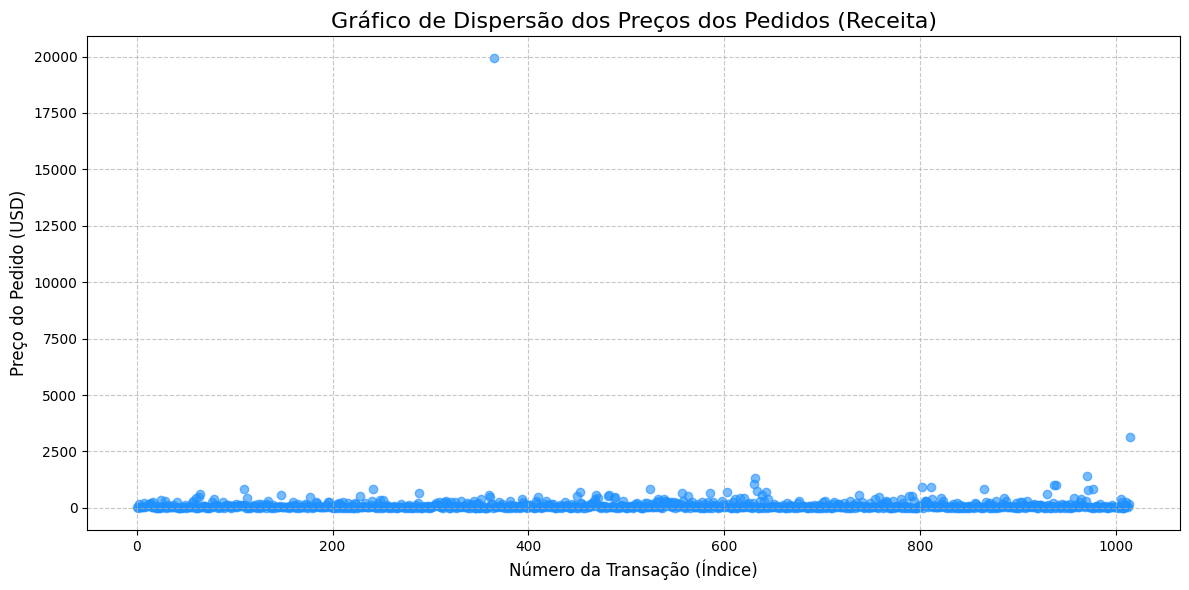

In [22]:
import matplotlib.pyplot as plt

# Plotar o gráfico de dispersão
plt.figure(figsize=(12, 6))

# O eixo X será o índice de cada pedido (para dispersão)
x_values = pd.Series(range(0, len(orders['revenue'])))

plt.scatter(x_values, orders['revenue'], alpha=0.6, color='dodgerblue')

# Configurações do título e eixos
plt.title('Gráfico de Dispersão dos Preços dos Pedidos (Receita)', fontsize=16)
plt.xlabel('Número da Transação (Índice)', fontsize=12)
plt.ylabel('Preço do Pedido (USD)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


A análise do gráfico de dispersão identifica perfeitamente o problema central que afeta as métricas monetárias (Receita e AOV), o gráfico é a confirmação visual final do que foi visto nos picos de Receita e AOV.

Há uma clara concentração de pedidos de compradores comuns. A vasta maioria dos pontos no gráfico está agrupada na base próxima ao eixo X, na faixa de 0 à aproximadamente 2.500 USD no eixo Y. Isso representa a base de compradores comuns e o valor médio dos pedidos da loja. Há pouquíssimos pontos isolados que voam muito acima desta concentração, sendo a identificação dos super compradores, ou seja, os outliers extremos.

**A causa dos números contaminados são estes pontos isolados, ou seja, são os outliers de Receita que, quando somados no cálculo acumulado, causam o pico abrupto na Receita Acumulada do Grupo B** e, consequentemente, distorcem o Ticket Médio Acumulado (AOV), como visto na linha do gráfico gerado anteriormente.

Minha análise é precisa ao conectar os dois tipos de outliers. O primeiro são os **outliers de Volume (3 pedidos ou mais)** que afetam a Taxa de Conversão, pois apenas 1% dos usuários compram 3 ou mais pedidos, resultado conforme o percentil 99 igual a 2. O segundo são os **outliers de Receita (pedidos maiores que 2.500 USD)** que afetam a Receita e o AOV. **É necessário remover ambos os tipos de outliers para garantir que o resultado estatístico reflita o comportamento da massa de usuários.**

O gráfico nos mostra que, visualmente, o valor de pedido começa a se tornar anômalo a partir de aproximadamente 2.500 USD. Para definir um limite de corte estatisticamente justificado, é preciso calcular os percentis 95 e 99 especificamente para a Receita, valor dos pedidos.

### 8. Cálculo dos percentis 95 e 99 dos preços dos pedidos (Receita).

A próxima etapa é exatamente essa, calcular os percentis 95 e 99 dos preços dos pedidos e usar essa informação para definir um limite numérico e filtrar os dados.

Vou finalizar a etapa de identificação de outliers calculando os percentis para o valor dos pedidos (Receita). Essa etapa é fundamental para definir um limite numérico para remover os super pedidos que causaram a distorção no AOV (Ticket Médio Acumulado).

Este cálculo tem como objetivo quantificar a anomalia em um valor monetário específico, traduzindo a observação visual do gráfico de dispersão, onde o aglomerado termina e os pontos isolados começam.

Aqui finalmente com esses percentis será possível usar esse montante monteário específico como o critério estatístico para determinar qual valor de pedido é alto o suficiente para ser considerado uma anomalia (outlier) e, portanto, ser excluído da análise de significância estatística.

In [23]:
import numpy as np

# Calcular os percentis 95 e 99 para o valor dos pedidos (Receita)
percentiles_revenue = np.percentile(orders['revenue'], [95, 99])

print("Percentis para o Valor dos Pedidos (Receita)")
print(f"Percentil 95 (P95) para o preço dos pedidos: {round(percentiles_revenue[0], 2)} USD")
print(f"Percentil 99 (P99) para o preço dos pedidos: {round(percentiles_revenue[1], 2)} USD")

Percentis para o Valor dos Pedidos (Receita)
Percentil 95 (P95) para o preço dos pedidos: 414.28 USD
Percentil 99 (P99) para o preço dos pedidos: 830.3 USD


Com os valores de percentil calculados, a análise dos outliers monetários está concluída. 

O Percentil 99 (P99) de 830.30 USD define o valor de corte para a receita. **Isso significa que 99% de todos os pedidos feitos durante o Teste A/B tiveram um valor igual ou inferior a 830.30 USD.** Consequentemente, para a análise estatística, considero que qualquer pedido com valor superior a 830.30 USD é uma anomalia, ou seja, outlier de receita. 

O P95 de 414.28 USD mostra que apenas 5% dos pedidos ultrapassam esse valor. No entanto, para ser conservador e manter a maior quantidade possível de dados válidos, decido usar o limite do P99 (830.30 USD). Ao remover apenas o 1% mais caro dos pedidos (aqueles acima de 830.30 USD), neutralizo os picos extremos vistos nos gráficos de Receita e AOV sem remover dados que representam uma fatia grande de clientes.

O P95 atua como uma âncora que mostra o quão concentrada está a maioria dos dados, reforçando a ideia de que o salto para o P99 já é significativo e um corte em 830.30 USD é um critério sólido, efizaz e estatisticamente defensável.

Em suma, agora tenho todos **os limites de anomalia definidos: (Volume: 3 ou mais pedidos) e (Receita > 830.30 USD).**


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Percentis e gráficos de dispersão implementados corretamente.

</div>

### 9. Teste de significância estatística na Taxa de Conversão (diferença na conversão entre os grupos usando os DADOS BRUTOS).

**O Teste de Significância Estatística é o que transforma a observação visual ("B está acima de A") em uma conclusão científica e acionável.** O teste dirá a probabilidade de a diferença observada na conversão (B sendo superior a A) ser resultado do acaso, sorte ou ruído aleatório. Se o resultado for estatisticamente significativo, podemos ter confiança de que a variante B é genuinamente melhor.

No mundo dos negócios, só deve implementar uma mudança se o teste mostrar que o risco de estar errado é baixo (geralmente menos de 5%, ou p < 0.05). Aplico o teste na conversão com dados brutos porque, como bem observado, a métrica de Conversão é menos afetada pelos outliers de valor. Embora os outliers de volume (3 pedidos ou mais) existam, o teste inicial dará uma visão de todo o impacto da variante, antes de fazermos qualquer limpeza.

Opto pelo pelo teste Mann-Whitney U em vez de testes paramétricos, como por exemplo, o teste t de Student, em razão da natureza dos dados. Os dados de pedidos e conversão em um Teste A/B raramente seguem uma distribuição normal, especialmente a conversão e o AOV. **O Teste Mann-Whitney U é um teste não-paramétrico, o que significa que ele não faz suposições sobre a distribuição dos dados, sendo muito mais sólido e confiável para dados de e-commerce com outliers e distribuições assimétricas.**

In [24]:
from scipy import stats as st
import numpy as np

# Preparação das amostras de conversão

# Criar uma lista de usuários que fizeram pedidos (1) e usuários que não fizeram (0)
# Obter usuários e número de pedidos
orders_by_user_A = orders[orders['group'] == 'A'].groupby('visitor_id', as_index=False).agg(
    {'transaction_id': 'nunique'}
)
orders_by_user_A.columns = ['visitor_id', 'orders']

orders_by_user_B = orders[orders['group'] == 'B'].groupby('visitor_id', as_index=False).agg(
    {'transaction_id': 'nunique'}
)
orders_by_user_B.columns = ['visitor_id', 'orders']


# Obter o total de visitas (para incluir os que não compraram)
total_visitors_A = visits[visits['group'] == 'A']['visits'].sum()
total_visitors_B = visits[visits['group'] == 'B']['visits'].sum()

# Criar a amostra final de Conversão (Amostras: 0s e 1s)
# Amostra A: [Pedidos do usuário 1, Pedidos do usuário 2, ...] + [0, 0, ...] para quem não comprou
sampleA = pd.concat([
    orders_by_user_A['orders'],
    pd.Series(0, index=np.arange(total_visitors_A - len(orders_by_user_A['orders'])), name='orders')
], axis=0)

# Amostra B: (Similar ao A)
sampleB = pd.concat([
    orders_by_user_B['orders'],
    pd.Series(0, index=np.arange(total_visitors_B - len(orders_by_user_B['orders'])), name='orders')
], axis=0)


# Aplicação do Teste Mann-Whitney U
alpha = 0.05  # Nível de significância padrão (5%)

# O teste é aplicado nas amostras de 0s e 1s (Taxa de Conversão)
p_value = st.mannwhitneyu(sampleA, sampleB, alternative='two-sided').pvalue

# Cálculo da Diferença Relativa (Lift)
relative_conversion_difference = sampleB.mean() / sampleA.mean() - 1

# Apresentação dos resultados
print("Teste de Significância da Taxa de Conversão (Dados Brutos)")
print(f"P-valor (Mann-Whitney U): {p_value:.3f}")

if p_value < alpha:
    print(f"Resultado: REJEITAMOS a Hipótese Nula (p-valor < {alpha})")
    print("Conclusão: A diferença na Taxa de Conversão é ESTATISTICAMENTE SIGNIFICATIVA.")
else:
    print(f"Resultado: NÃO REJEITAMOS a Hipótese Nula (p-valor >= {alpha})")
    print("Conclusão: A diferença na Taxa de Conversão PODE ser resultado do acaso.")

print(f"Diferença Relativa (Lift) B/A: {relative_conversion_difference:.2%}")

Teste de Significância da Taxa de Conversão (Dados Brutos)
P-valor (Mann-Whitney U): 0.011
Resultado: REJEITAMOS a Hipótese Nula (p-valor < 0.05)
Conclusão: A diferença na Taxa de Conversão é ESTATISTICAMENTE SIGNIFICATIVA.
Diferença Relativa (Lift) B/A: 15.98%


O P-valor em 0.011 é muito menor que o limite de erro aceitável de 0.05. O resultado estatístico	"REJEITAMOS a Hipótese Nula" quer dizer que a diferença observada entre os grupos não é resultado do acaso. A diferença Relativa (Lift) em 15.98% significa que o Grupo B (Variante) tem uma Taxa de Conversão quase 16% maior que o Grupo A (Controle). **A conclusão principal é uma ação imediata de que a Variante B é estatisticamente vencedora na conversão.**

O teste comprova com o p-valor de 0.011, que existe apenas 1.1% de chance de erro de que a mudança implementada no Grupo B, realmente incentivou mais visitantes a fazerem um pedido. A diferença de quase 16% é o lift, ou seja, uma porcentagem de melhoria substancial e significativo para o negócio.

Com isso, **existe a validação da hipótese escolhida pelo RICE. A hipótese "Add a subscription form to all the main pages...") provou ser eficaz.** O alto alcance (Reach) da hipótese no RICE foi bem-sucedido em converter uma maior proporção da base de usuários.

E ainda, mesmo com a presença de outliers de volume (3 pedidos ou mais), o efeito da variante é tão forte que a diferença se manteve estatisticamente significativa. Isso reforça a solidez da descoberta na métrica de comportamento do usuário.

### 10. Teste de Significância estatistica do AOV (diferença no tamanho médio do pedido entre os grupos usando os DADOS BRUTOS). 

Agora que a Conversão está decidida com a validação da hipótese escolhida pelo RICE, eu preciso fechar a análise financeira, pois o AOV (Ticket Médio) ainda está distorcido pelos outliers monetários.

Essa etapa é de extrema importância para o veredito final. A ação é aplicar o Teste Mann-Whitney U no AOV utilizando os dados brutos, sendo esse resultado essencial para entender a magnitude da distorção causada pelos outliers que foi identificado no Ticket Médio.

In [25]:
from scipy import stats as st
import numpy as np

# Nível de significância padrão
alpha = 0.05

# Separar as amostras de receita (valor do pedido) por grupo
# A amostra A é a receita de todos os pedidos do Grupo A
sample_revenue_A = orders[orders['group'] == 'A']['revenue']

# A amostra B é a receita de todos os pedidos do Grupo B
sample_revenue_B = orders[orders['group'] == 'B']['revenue']

# Aplicação do Teste Mann-Whitney U
# Estamos testando se os valores médios (medianas, na verdade) das amostras são diferentes.
p_value_revenue = st.mannwhitneyu(sample_revenue_A, sample_revenue_B, alternative='two-sided').pvalue

# Cálculo da Diferença Relativa no AOV (Lift)
# Uso a média da Receita dos pedidos para calcular o AOV médio de cada grupo
aov_A = sample_revenue_A.mean()
aov_B = sample_revenue_B.mean()
relative_aov_difference = aov_B / aov_A - 1

# Apresentação dos Resultados
print("Teste de Significância do AOV (Dados Brutos)")
print(f"P-valor (Mann-Whitney U): {p_value_revenue:.3f}")

if p_value_revenue < alpha:
    print(f"Resultado: REJEITAMOS a Hipótese Nula (p-valor < {alpha})")
    print("Conclusão: A diferença no AOV é ESTATISTICAMENTE SIGNIFICATIVA.")
else:
    print(f"Resultado: NÃO REJEITAMOS a Hipótese Nula (p-valor >= {alpha})")
    print("Conclusão: A diferença no AOV PODE ser resultado do acaso, ou a diferença está mascarada pelos outliers.")

print(f"Diferença Relativa (Lift) B/A: {relative_aov_difference:.2%}")

Teste de Significância do AOV (Dados Brutos)
P-valor (Mann-Whitney U): 0.862
Resultado: NÃO REJEITAMOS a Hipótese Nula (p-valor >= 0.05)
Conclusão: A diferença no AOV PODE ser resultado do acaso, ou a diferença está mascarada pelos outliers.
Diferença Relativa (Lift) B/A: 27.83%


A análise do Ticket Médio (AOV) nos Dados Brutos acima confirmou exatamente o esperado ao analisar os gráficos. Este resultado é a prova estatística da distorção que foi identificada.

Este resultado cria um paradoxo que valida toda a análise anterior de outliers. A visão bruta do Lift em 27.83% permite entender que o Grupo B parece ter um ticket médio (AOV) muito superior em relação ao Grupo A. Estatisticamente, o teste diz que essa diferença maciça de quase 28% é aleatória. A chance de a diferença ser resultado do acaso é de 86.2% (P-valor em 0.862).

Isso acontece porque o pico de outliers extremos, como pedidos de 10.000 USD e 20.000 USD, é tão grande que distorce a média. O Teste Mann-Whitney U, sendo não-paramétrico, é mais resistente a valores extremos do que um teste t, e ele percebe que, embora as médias sejam diferentes, a distribuição dos dados subjacentes (a maioria dos pedidos) é muito parecida. A diferença que existe é esmagadoramente causada pelo ruído dos outliers, e não pela eficácia da variante.

Dessa forma, **para tomar uma decisão acionável e final, se faz primordial eliminar o ruído e refazer o teste. Mais do que nunca, é essencial testar se a diferença no ticket médio (AOV) é significativa entre os clientes típicos (os 99% que não são outliers), eliminando do teste os denominados super compradores.** Ou seja, é preciso filtrar os dados no teste de significância estatística.

### 11. Teste de Significância estatística na Taxa de Conversão (diferença na conversão entre os grupos usando os DADOS FILTRADOS).

Essa etapa é a última antes de dar o veredito final do Teste A/B, isto é, filtrar os dados de Conversão e refazer o teste do AOV (ticket médio) também com os dados limpos sem outliers, ou seja, sem os usuários com 3 ou mais pedidos, e sem os pedidos com valor acima de 830.30 USD, aplicando o Teste Estatístico (Mann-Whitney U) nas amostras de receita filtradas.

Essa ação revelará se a hipótese B tem um AOV genuinamente maior para o cliente médio ou se, uma vez removido o ruído provocado pelos outliers, a diferença desaparece.

In [26]:
# Definir os limites de anomalia
ORDERS_LIMIT = 2 # Usuários com 3 ou mais pedidos são outliers
REVENUE_LIMIT = 830.3 # Pedidos acima de 830.30 USD são outliers

# Identificar outliers de Volume (Usuários com 3 ou mais pedidos)
orders_by_user_count = orders.groupby('visitor_id', as_index=False).agg(
    {'transaction_id': 'nunique'}
)
# Lista de IDs de usuários com volume anormal
abnormal_users_volume = orders_by_user_count[orders_by_user_count['transaction_id'] > ORDERS_LIMIT]['visitor_id']

# Identificar outliers de Receita (Pedidos acima do limite)
# Lista de IDs de usuários que fizeram pedidos com valor anormal
abnormal_users_revenue = orders[orders['revenue'] > REVENUE_LIMIT]['visitor_id']

# Combinar todas as IDs de outliers
abnormal_users = pd.concat([abnormal_users_volume, abnormal_users_revenue], axis=0).drop_duplicates()

# Filtrar o DataFrame de pedidos (orders_filtered)
orders_filtered = orders[~orders['visitor_id'].isin(abnormal_users)]

print(f"Número total de usuários outliers removidos: {len(abnormal_users)}")
print(f"Pedidos restantes após a filtragem: {len(orders_filtered)}")

Número total de usuários outliers removidos: 16
Pedidos restantes após a filtragem: 986


In [27]:
from scipy import stats as st
import numpy as np

alpha = 0.05

# Preparação das Amostras de Conversão (0s e 1s) a partir de orders_filtered

# Usuários que fizeram pedidos (agora filtrados)
orders_by_user_A_filtered = orders_filtered[orders_filtered['group'] == 'A'].groupby('visitor_id', as_index=False).agg(
    {'transaction_id': 'nunique'}
)
orders_by_user_B_filtered = orders_filtered[orders_filtered['group'] == 'B'].groupby('visitor_id', as_index=False).agg(
    {'transaction_id': 'nunique'}
)

# Total de visitantes (continua o mesmo, pois não removi visitantes que não compraram)
total_visitors_A = visits[visits['group'] == 'A']['visits'].sum()
total_visitors_B = visits[visits['group'] == 'B']['visits'].sum()

# Amostra A Filtrada: [Pedidos de usuários filtrados] + [0, 0, ...] para quem não comprou
sampleA_filtered = pd.concat([
    orders_by_user_A_filtered['transaction_id'],
    pd.Series(0, index=np.arange(total_visitors_A - len(orders_by_user_A_filtered['transaction_id'])), name='orders')
], axis=0)

# Amostra B Filtrada: (Similar ao A)
sampleB_filtered = pd.concat([
    orders_by_user_B_filtered['transaction_id'],
    pd.Series(0, index=np.arange(total_visitors_B - len(orders_by_user_B_filtered['transaction_id'])), name='orders')
], axis=0)


# Aplicação do Teste Mann-Whitney U
p_value_conversion_filtered = st.mannwhitneyu(sampleA_filtered, sampleB_filtered, alternative='two-sided').pvalue

# Cálculo da Diferença Relativa (Lift)
relative_conversion_difference_filtered = sampleB_filtered.mean() / sampleA_filtered.mean() - 1

# Apresentação dos Resultados
print("Teste de Significância da Taxa de Conversão (Dados FILTRADOS)")
print(f"P-valor (Mann-Whitney U): {p_value_conversion_filtered:.3f}")

if p_value_conversion_filtered < alpha:
    print(f"Resultado: REJEITAMOS a Hipótese Nula (p-valor < {alpha})")
    print("Conclusão: A diferença na Taxa de Conversão é ESTATISTICAMENTE SIGNIFICATIVA.")
else:
    print(f"Resultado: NÃO REJEITAMOS a Hipótese Nula (p-valor >= {alpha})")
    print("Conclusão: A diferença na Taxa de Conversão PODE ser resultado do acaso.")

print(f"Diferença Relativa (Lift) B/A: {relative_conversion_difference_filtered:.2%}")

Teste de Significância da Taxa de Conversão (Dados FILTRADOS)
P-valor (Mann-Whitney U): 0.007
Resultado: REJEITAMOS a Hipótese Nula (p-valor < 0.05)
Conclusão: A diferença na Taxa de Conversão é ESTATISTICAMENTE SIGNIFICATIVA.
Diferença Relativa (Lift) B/A: 18.95%


Este resultado final na Taxa de Conversão é extremamente forte e conclusivo, ele solidifica a vitória do Grupo B (Variante) na métrica de comportamento do usuário, mesmo após a limpeza.

O P-valor de 0.007 é ainda menor que o p-valor com os dados brutos. Isso significa que a chance de a diferença ser resultado do acaso caiu para menos de 0.7%. A diferença na Taxa de Conversão é estatisticamente significativa e a Hipótese Nula (que diz que não há diferença) é rejeitada com alta confiança. Já a diferença relativa (Lift) aumentou de 15.98% para 18.95%. Isso indica que, ironicamente, os 16 usuários outliers removidos tinham uma Taxa de Conversão ligeiramente pior do que o cliente médio, e removê-los limpou o ruído, revelando o verdadeiro lift da variante B.

**A hipótese do Grupo B (Variante) é um sucesso comprovado na métrica de comportamento. Ela converte quase 19% mais visitantes em compradores em comparação com o Grupo A (Controle).** No entanto, embora a Taxa de Conversão seja uma vitória clara, **a decisão final de implementação da variante B ainda depende do seu impacto financeiro (AOV e Receita) com a aplicação do teste de significância estatítica do ticket médio entre os grupos filtrados.**

### 12. Teste de Significância estatística do AOV (diferença no tamanho médio do pedido entre os grupos usando os DADOS FILTRADOS).

O objetivo agora é descobrir se a variante B, além de aumentar a conversão em quase 19%, também aumenta o valor gasto pelo cliente médio. Para isso, irei aplicar o teste no AOV usando os dados filtrados.

In [28]:
from scipy import stats as st

# Nível de significância padrão
alpha = 0.05

# Separar as amostras de receita (valor do pedido) por grupo no DATAFRAME FILTRADO
# A amostra A é a receita de todos os pedidos filtrados do Grupo A
sample_revenue_A_filtered = orders_filtered[orders_filtered['group'] == 'A']['revenue']

# A amostra B é a receita de todos os pedidos filtrados do Grupo B
sample_revenue_B_filtered = orders_filtered[orders_filtered['group'] == 'B']['revenue']

# Aplicação do Teste Mann-Whitney U (Dados Limpos)
p_value_aov_filtered = st.mannwhitneyu(sample_revenue_A_filtered, sample_revenue_B_filtered, alternative='two-sided').pvalue

# Cálculo da Diferença Relativa no AOV (Lift)
aov_A_filtered = sample_revenue_A_filtered.mean()
aov_B_filtered = sample_revenue_B_filtered.mean()
relative_aov_difference_filtered = aov_B_filtered / aov_A_filtered - 1

# Apresentação dos resultados
print("Teste de Significância do AOV (Ticket Médio) - Dados FILTRADOS")
print(f"P-valor (Mann-Whitney U): {p_value_aov_filtered:.3f}")

if p_value_aov_filtered < alpha:
    print(f"Resultado: REJEITAMOS a Hipótese Nula (p-valor < {alpha})")
    print("Conclusão: A diferença no AOV é ESTATISTICAMENTE SIGNIFICATIVA.")
else:
    print(f"Resultado: NÃO REJEITAMOS a Hipótese Nula (p-valor >= {alpha})")
    print("Conclusão: A diferença no AOV PODE ser resultado do acaso.")

print(f"Diferença Relativa (Lift) B/A: {relative_aov_difference_filtered:.2%}")

Teste de Significância do AOV (Ticket Médio) - Dados FILTRADOS
P-valor (Mann-Whitney U): 0.822
Resultado: NÃO REJEITAMOS a Hipótese Nula (p-valor >= 0.05)
Conclusão: A diferença no AOV PODE ser resultado do acaso.
Diferença Relativa (Lift) B/A: -3.19%


Este resultado final do AOV (Ticket Médio) com os dados filtrados é o veredicto completo e definitivo do Teste A/B para o e-commerce.

Com a eliminação dos dados distorcidos pelos outliers, o Teste AOV com dados filtrados funcionou como planejado. A remoção dos outliers de Receita, acima de 830.30 USD, fez com que o Lift caísse de +27.83% para -3.19%. O ticket médio (AOV) é neutro, o P-valor de 0.822 é extremamente alto. Isso significa que a chance de haver uma diferença real no Ticket Médio entre os grupos A e B é mínima.

O veredito do teste de que "NÃO REJEITAMOS a Hipótese Nula" para o AOV, me faz **concluir que a variante B não teve impacto estatisticamente significativo no valor que o cliente médio gasta por pedido**, ou seja, o veredicto geral do Teste A/B é uma vitória parcial e definitiva para o Grupo B.

A variante B deve ser implementada e substituída pela versão do grupo A. O ganho de quase 19% na Taxa de Conversão é um benefício substancial e significativo para o negócio (aumento de volume). Como o AOV não caiu significativamente (o -3.19% é apenas ruído), o aumento de conversão é um ganho líquido para a receita total. O custo de oportunidade de não implementar o aumento de 18.95% na conversão é muito alto. 

A hipótese focada no Alcance/Conversão funcionou. A próxima estratégia do Teste A/B deve focar agora em como aumentar o AOV, por exemplo, a recomendação de produtos, frete grátis condicional, pois a variante atual não conseguiu isso. 

Minha recomendação final é de que **o teste A/B para a hipótese "Add a subscription form to all the main pages..." é um sucesso comprovado e deve ser implantado.**

### 13. Sumário final dos resultados do Teste A/B.

A tomada de decisão deve ser baseada nos dois testes de significância mais robustos usando os dados filtrados da Taxa de Conversão e o ticket médio (AOV). E com base na análise estatística final, **os dados apresentados fornecem uma direção clara para a tomada de decisão.**

A métrica Taxa de Conversão, sendo o fator decisivo, mostrou um ganho estatisticamente significativo de +18.95% a favor do Grupo B, validado por um P-valor extremamente baixo (0.007). Isso comprova que a variante B é eficaz em aumentar o volume de clientes. Em contraste, a métrica AOV (Ticket Médio) apresentou um P-valor alto (0.822), indicando que a diferença de -3.19% é mero ruído e não é estatisticamente significativa. 

**A conclusão final é que o Grupo B é claramente o líder, pois ele melhora drasticamente a conversão sem prejudicar o valor médio do pedido, tornando a sua implementação imediata a escolha mais lucrativa e estatisticamente justificada para o negócio,** sendo portanto o Grupo B líder na testagem.

Para essa decisão, minha justificativa é de que a variante B demonstrou um aumento na Taxa de Conversão que é estatisticamente significativo. Com um P-valor de 0.007, há menos de 0.7% de chance de que o aumento de 18.95% na conversão seja um mero acaso. O AOV (Ticket Médio) se mostrou estatisticamente neutro em p=0.822. O pequeno declínio de -3.19% após a remoção dos outliers é considerado ruído aleatório e não uma diferença real. 

Uma vez que o AOV não foi impactado negativamente de forma significativa, o ganho de quase 19% na conversão se traduz diretamente em um aumento líquido no volume total de pedidos e na receita total. Ademais, os gráficos acumulados de Taxa de Conversão e a estabilidade do AOV após a limpeza indicam que o teste atingiu a duração necessária para estabilizar os resultados e tirar conclusões firmes.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Os testes foram formulados, implementados e analisados corretamente. Muito bom!
</div>


### 14. Ações recomendadas (próximos passos de negócio para o e-commerce).

Para completar o ciclo do Teste A/B, sugiro algumas ações de negócio a serem tomadas. Uma delas é a **implementação imediata da variante B para 100% dos usuários, substituindo o Grupo A (Controle)**. Outro ponto é o monitoramento, **o desempenho deve ser monitorado por algumas semanas após a implementação para garantir que o lift (melhoria) de 18.95% se mantenha no ambiente de produção**, o que é conhecido como Teste AA pós-implementação.

E por fim, como a variante B resolveu o problema de conversão quanto ao volume de pedidos, **a próxima prioridade da loja online no Teste A/B deve focar em aumentar o AOV (Ticket Médio)**, que ainda está estagnado, aplicando ações como por exemplo, testar novas recomendações de produtos ou ofertas de frete grátis por valor.

**Bruno Trindade**